# Sampling Variability

**Goals**  
- Explain sampling variability and why repeated samples differ  
- Visualize sampling distributions with simulation  
- Connect standard error to sample size  
- Recognize law of large numbers behavior


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()


```{contents}
:local:
:depth: 2
```


We will simulate many samples from a Bernoulli process (think weighted coin with $p=0.6$ for heads) to see how sample proportions vary.

Key quantities:
- True proportion $p$  
- Sample size $n$  
- **Sample proportion** $\hat p$  
- **Sampling distribution**: distribution of $\hat p$ across repeated samples


## Simulating Sample Proportions

In [2]:
rng = np.random.default_rng(seed=0)

p_true = 0.6
n = 40
n_sims = 5_000

# Draw many samples and compute sample proportions
samples = rng.binomial(n=n, p=p_true, size=n_sims)      # Draw samples from a binomial distribution
sample_props = samples / n                              # Compute sample proportions    

summary = pd.Series(sample_props).describe(percentiles=[0.025, 0.5, 0.975]).round(3)
summary


count    5000.000
mean        0.600
std         0.078
min         0.350
2.5%        0.450
50%         0.600
97.5%       0.750
max         0.850
dtype: float64

We see that 

- 97.5% of the simulated sample proportions fell at or below 0.750.
- 2.5%, the lower bound, is 0.450.
- the middle 95% of simulated proportions fall between 0.45 and 0.75.

Now let us take a look at the sample distribution: he distribution of sample proportions (`sample_props`) generated from 5,000 simulated samples.

## Sampling Distribution

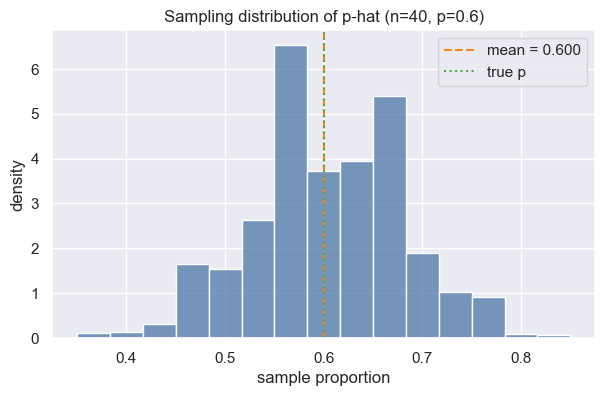

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(sample_props, bins=15, stat="density", color="#4c78a8", edgecolor="white", ax=ax)

ax.axvline(sample_props.mean(), color="#f58518", linestyle="--", label=f"mean = {sample_props.mean():.3f}")
ax.axvline(p_true, color="#54a24b", linestyle=":", label="true p")
ax.set(xlabel="sample proportion", ylabel="density", title="Sampling distribution of p-hat (n=40, p=0.6)")
ax.legend()
plt.show()


## Standard Error

For a sample proportion, the **standard error** measures the typical deviation of $\hat p$ from $p$:

$\text{SE}(\hat p) = \sqrt{\dfrac{p(1-p)}{n}}$

If $p$ is unknown, we often plug in $\hat p$. In real data analysis you don't know p, so you'd substitute it with p-hat instead. It's an approximation, but a good one for large n.

$SE$ is what "sampling variability" is, expressed as a single number. p-hat is the sample proportion, e.g., 0.6. 

The standard deviation of the sampling distribution (simulation/empirical) of p-hat is the standard error by definition. 


Note that: 

- `p(1−p)` is the variance of a single observation. It captures how much "spread" there is in one yes/no trial.
  - `p(1−p)` is maximized at p=0.5 (most uncertain) and shrinks as p approaches 0 or 1.
  - e.g. if p=0.6 → 0.6×0.4 = 0.24
- "**plug in p̂**": In real life you don't know p (that's why you're sampling!), so you substitute your observed `p̂` into the formula. It's an approximation, but it works well for reasonably large `n`.

Here we compare the empirical SD of simulations vs. the theoretical SE, to confirm that they match.
In the comparison below, `ddof` stands for Delta Degrees of Freedom. It controls the denominator used in the std calculation. If ddof=0, divides by n (population std); if ddof=1, divides by n−1 (sample std).

- The theoretical SE is the formula applied to the known values: 

    ```text
    sqrt(0.6 × (1-0.6) / 40) ≈ 0.0775.
    ```

- The empirical SE is the standard deviation of the 5,000 simulated p-hat values -- no formula, purely from the simulation.

- If the theoretical SE comes out nearly identical with the empirical (simulation) SE, the it validates that the formula is correct and the simulation is working as expected.



In [4]:
se_theoretical = np.sqrt(p_true * (1 - p_true) / n)
se_empirical = sample_props.std(ddof=1)

print(f"Theoretical SE: {se_theoretical:.4f}")
print(f"Simulated SE:   {se_empirical:.4f}")


Theoretical SE: 0.0775
Simulated SE:   0.0781


## Effect of Sample Size

Larger samples shrink variability. Below we compare sampling distributions (p-hats) across different $n$ while keeping $p=0.6$ fixed.


,n,mean(p-hat),sd(p-hat),SE formula
0,10,0.5994,0.1549,0.1549
1,40,0.5984,0.0780,0.0775
2,200,0.5986,0.0348,0.0346


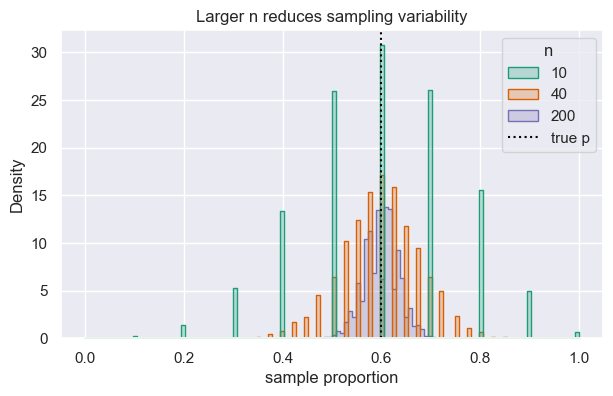

In [5]:
def simulate_props(n, p=0.6, sims=5_000):
    props = rng.binomial(n=n, p=p, size=sims) / n   # Simulate sample proportions by drawing from a binomial distribution and dividing by n
    return props

ns = [10, 40, 200]
records = []
frames = []
for n_i in ns:
    props_i = simulate_props(n=n_i)
    frames.append(pd.DataFrame({"n": n_i, "prop": props_i}))    # Store the sample proportions in a DataFrame for plotting
    records.append({
        "n": n_i,
        "mean(p-hat)": props_i.mean(),
        "sd(p-hat)": props_i.std(ddof=1),
        "SE formula": np.sqrt(p_true * (1 - p_true) / n_i)
    })

display(pd.DataFrame(records).round(4))

plot_df = pd.concat(frames, ignore_index=True)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=plot_df, x="prop", hue="n", element="step", stat="density", common_norm=False, palette="Dark2", ax=ax)
vline = ax.axvline(p_true, color="black", linestyle=":")
ax.set(xlabel="sample proportion", title="Larger n reduces sampling variability")

leg = ax.get_legend()
handles = list(leg.legend_handles) + [vline]
labels = [t.get_text() for t in leg.get_texts()] + ["true p"]
ax.legend(handles=handles, labels=labels, title="n")
plt.show()


**Takeaways**  
- Repeated samples vary; summarizing their distribution clarifies how much.  
- Standard error captures typical sampling fluctuation and shrinks as $n$ grows.  
- Simulations help check formulas and build intuition about variability.

As 𝑛 gets larger, the 𝑝-hat values from repeated samples cluster more tightly around the true 𝑝. In the plot, the histogram for 𝑛 = 200 is much narrower than for 𝑛 = 10 — the same true 𝑝 = 0.6, but larger samples give you estimates that are consistently closer to it.

Concretely, the SE formula shows why: SE = sqrt(𝑝(1−𝑝)/𝑛), so as 𝑛 increases, SE decreases. A larger sample gives you more information, so your estimate is less noisy.


## Section Practice

Use this short exercise to check the main workflow from this section.


In [6]:
### Exercise: Compute Evidence for Sampling Variability
# Use the sample values below to summarize a small business metric.
# Calculate the mean and the distance between the largest and smallest values.
# Print both values.
values = [18, 21, 19, 25, 22]
### Your code starts here




### Your code ends here


In [7]:
### Solution
values = [18, 21, 19, 25, 22]
mean_value = sum(values) / len(values)
spread = max(values) - min(values)
print("Mean:", mean_value)
print("Spread:", spread)


Mean: 21.0
Spread: 7
